# Exercise 5:  The perceptron

In this notebook you will explore the perceptron algorithm.  For all questions use the scikit-learn [breast cancer dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) and use the implementation of the perceptron we looked at in class.


### Part 1: number of epochs

Explore the accuracy of the perceptron on the breast cancer dataset while varying the number of epochs that the perceptron is trained.  Measure accuracy on both the training and test sets and plot the results as a function of number of epochs (best to use a logarithmic axis for the x-axis, using plt.semilogx).  What can you conclude?


/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


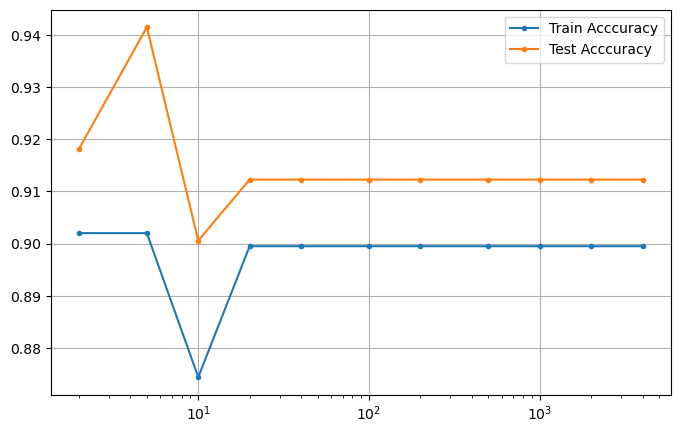

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

data = load_breast_cancer()
X = data.data
y = data.target
train_accuracy = []
test_accuracy = []
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)

num_epochs = [2, 5, 10, 20, 40, 100, 200, 500, 1000, 2000, 4000]

for epoch in num_epochs:
    p = Perceptron(max_iter = epoch, eta0 = 0.1)
    p.fit(X_train, y_train)

    # test accuracy
    y_pred = p.predict(X_test)
    test_accuracy.append(np.mean(y_test == y_pred))
    
    # training accuracy
    y_pred = p.predict(X_train)
    train_accuracy.append(np.mean(y_train == y_pred))

# plotting
plt.figure(figsize = (8, 5))
plt.semilogx(num_epochs, train_accuracy, marker = '.', label = "Train Acccuracy")
plt.semilogx(num_epochs, test_accuracy, marker = '.', label = "Test Acccuracy")
plt.legend()
plt.grid(True)
plt.show()

### Part 2

Can you tell if the breast cancer dataset is linearly separable?

**Thanks to the graph above, we can see that the breast cancer data set is *not* linearly separable. We can conclude this because there is no possible way to draw one singular straight line between both accuracy plots without hitting one.**

In [ ]:
# and if you want to have some code

### Part 3: the learning rate

How does the learning rate affect the accuracy of the perceptron?
To address this question, plot training and test accuracy as a function of the learning rate.
Again, use plt.semilogx for the x-axis to have a logarithmic scale for the x-axis.

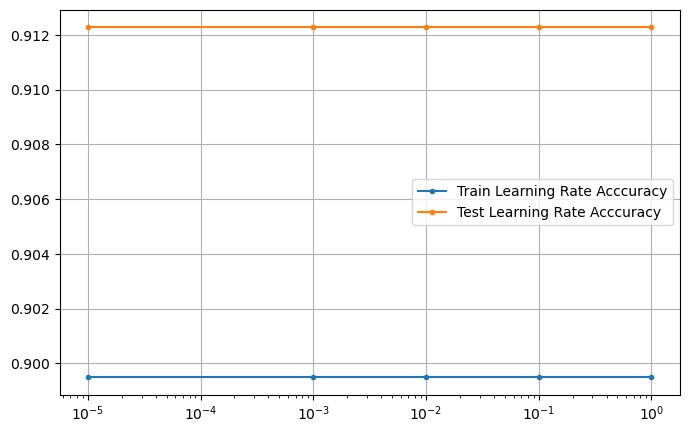

In [31]:
learning_rates = [0.00001, 0.001, 0.01, 0.1, 1]
train_lr_accuracy = []
test_lr_accuracy = []

for rate in learning_rates:
    p = Perceptron(max_iter = 20, eta0 = rate)
    p.fit(X_train, y_train)

    # test accuracy
    y_pred = p.predict(X_test)
    test_lr_accuracy.append(np.mean(y_test == y_pred))
    
    # training accuracy
    y_pred = p.predict(X_train)
    train_lr_accuracy.append(np.mean(y_train == y_pred))

# plotting
plt.figure(figsize = (8, 5))
plt.semilogx(learning_rates, train_lr_accuracy, marker = '.', label = "Train Learning Rate Acccuracy")
plt.semilogx(learning_rates, test_lr_accuracy, marker = '.', label = "Test Learning Rate Acccuracy")
plt.legend()
plt.grid(True)
plt.show()


**Since this data set is already linearly inseparable, the accuracy will plateu eventually, no matter what the learning rate is.**